In [1]:
import pandas as pd
import numpy as np

import joblib

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\processed\\X_train.csv")
X_test = pd.read_csv("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\processed\\X_test.csv")

y_train = pd.read_csv("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\processed\\y_train.csv").squeeze()
y_test = pd.read_csv("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\data\\processed\\y_test.csv").squeeze()

In [16]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

In [17]:
baseline_model.fit(
    X_train,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [18]:
y_pred = baseline_model.predict(X_test)

In [19]:
y_prob = baseline_model.predict_proba(X_test)[:,1]

In [20]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9752


In [21]:
precision = precision_score(
    y_test,
    y_pred
)

print(f"Precision : {precision:.4f}")

Precision : 0.0562


In [22]:
recall = recall_score(
    y_test,
    y_pred
)

print(f"Recall : {recall:.4f}")

Recall : 0.8737


In [23]:
f1 = f1_score(
    y_test,
    y_pred
)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.1057


In [24]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC AUC : {roc_auc:.4f}")

ROC AUC : 0.9658


In [26]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



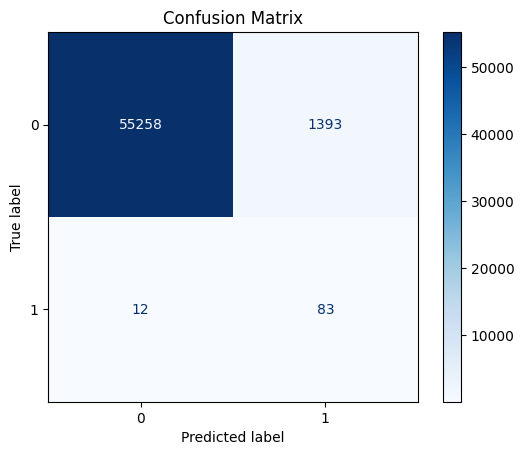

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [28]:
joblib.dump(
    baseline_model,
    "C:\\Users\\vipul\\Desktop\\Fraud_Detection\\ml\\logistic_regression.pkl"
)

print("Baseline Model Saved.")

Baseline Model Saved.
